# [2장 1강] 실습문제 - 데이터 정제 요소

## 실습 목표
- 결측치, 중복 데이터, 이상치의 발생 원인과 차이를 의료 예약 데이터에서 구분할 수 있습니다.
- MCAR / MAR / MNAR을 사례와 데이터 패턴을 근거로 구분할 수 있습니다.
- 이상치를 입력 오류 / 측정 오류 / 진짜 이상치로 구분할 수 있습니다.

## 중요
이번 강은 **탐지와 판단까지만** 합니다.

하지 않는 작업:
- `fillna()`, `dropna()`
- `drop_duplicates()`
- 이상치 삭제, 수정, 대체

```text
2장 1강 → 탐지 및 판단
2장 2강 → 결측치 처리
2장 3강 → 이상치 처리
```

## 사용 데이터
- `Medical_Appoingtment_No_Shows.csv`

## 실습 준비

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

appointments = pd.read_csv("Medical_Appoingtment_No_Shows.csv")

---

## 필수 1. 3대 정제 요소 구분하기

### 문제 1-1. 사례별 정제 요소와 발생 원인 판단

다음 사례를 `결측치 / 중복 데이터 후보 / 이상치 후보 / 정상 반복 구조` 중 하나로 분류하세요.

1. 특정 컬럼의 값이 비어 있다.
2. 같은 `AppointmentID`가 두 번 이상 등장한다.
3. `Age`가 -1로 기록되어 있다.
4. 같은 `PatientId`가 여러 예약 행에 반복 등장한다.

각 사례마다 아래를 작성하세요.
- 분류
- 발생 원인 추정
- 분석 영향
- 현재 단계에서 할 일
- 현재 단계에서 하면 안 되는 일

| 사례 | 분류 | 발생 원인 추정 | 분석 영향 | 현재 단계에서 할 일 | 하면 안 되는 일 |
|---|---|---|---|---|---|
| 값이 비어 있음 | 결측치 | 입력 누락, 시스템 수집 실패 | 집계 결과가 달라지거나 모델 학습에 사용할 정보 축소  | 결측 위치, 개수, 발생 패턴 확인 | 원인을 확인하지 않고 임의 삭제 |
| AppointmentID 반복 | 중복 데이터 후보 | 데이터 재적재, 이중 기록 | 동일 예약이 여러 건으로 계산되어 과다 집계  | 같은 예약이 실제로 중복 기록이 되었는지 확인 | 반복된 행을 바로 삭제|
| Age = -1 | 이상치 후보 | 입력 오류, 특수 코드 | 평균, 최솟값, 분포가 왜곡  |  데이터 정의서와 원본 입력값 확인| 임의로 0이나 평균값으로 수정하거나 삭제 |
| PatientId 반복 | 정상 반복 구조 | 한 환자가 여러번 예약 | 환자수와 예약 건수를 구분해서 해석해야 함 | 분석 단위가 환자 또는 예약인지 확인 필요 | 환자ID가 같다는 이유로 삭제 |

### 문제 1-2. 실제 데이터에서 중복 후보 탐지

**요구사항**
1. 전체 행 기준 완전 중복 수를 `duplicated()`로 확인하세요.
2. `AppointmentID` 기준 중복 수를 확인하세요.
3. `PatientId` 기준 반복 수를 확인하세요.
4. 세 결과를 비교해 해석하세요.

**질문**
- AppointmentID 중복은 왜 오류 후보인가요?
- PatientId 반복은 왜 정상일 수 있나요?
- 왜 바로 삭제하면 안 되나요?

In [13]:
# 문제 1-2 코드를 작성하세요.

appointments.duplicated().sum()
du_AppointmentID = appointments.duplicated(subset='AppointmentID')

du_AppointmentID

duplicate_rows = appointments.duplicated().sum()

print("전체 행 기준 완전 중복:", duplicate_rows)

appointment_id_duplicates = appointments["AppointmentID"].duplicated().sum()

print("AppointmentID 기준 중복:", appointment_id_duplicates)


patient_id_duplicates = appointments["PatientId"].duplicated().sum()

print("PatientId 기준 반복:", patient_id_duplicates)

전체 행 기준 완전 중복: 0
AppointmentID 기준 중복: 0
PatientId 기준 반복: 48228


---

## 필수 2. 결측 메커니즘 판단 — MCAR / MAR / MNAR

### 문제 2-1. 결측 패턴 확인하기

**요구사항**
1. 컬럼별 결측치 개수를 확인하세요.
2. 결측치가 있는 컬럼을 기록하세요.
3. 다음 개념을 정리하세요.
   - MCAR: 결측 여부가 다른 변수와 무관
   - MAR: 결측 여부가 다른 관측 변수와 관련
   - MNAR: 결측 여부가 결측된 값 자체와 관련
4. 실제 Medical Appointment 데이터에서 결측이 거의 없거나 없다면, 실제 패턴만으로 메커니즘을 확정하기 어렵다고 작성하세요.
5. 다음 사례를 분류하세요.

- 사례 A: 서버 장애로 일부 예약의 Age가 무작위 유실
- 사례 B: 고령 환자일수록 특정 문진 응답 누락이 많음
- 사례 C: 민감한 건강 상태가 심한 환자일수록 해당 항목 응답을 의도적으로 비움

In [12]:
# 문제 2-1 코드를 작성하세요.

missing_count = appointments.isnull().sum()

print("컬럼별 결측치 개수:")
print(missing_count)

missing_columns = missing_count[missing_count > 0]

print("결측치가 있는 컬럼:")
print(missing_columns)


컬럼별 결측치 개수:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64
결측치가 있는 컬럼:
Series([], dtype: int64)


### 문제 2-1 결과 해석
- 결측치가 있는 컬럼:
- 실제 데이터만으로 메커니즘 확정 가능 여부:
- 사례 A:
- 사례 B:
- 사례 C:
- 가장 처리하기 어려운 메커니즘과 이유: MAR

---

## 심화 1. 이상치 유형 구분과 처리 방향 판단

### 문제 3-1. Age 이상치 후보 탐지

**요구사항**
1. `Age.describe()`를 확인하세요.
2. 박스플롯을 그리세요.
3. IQR 기준 이상치 후보를 탐지하세요.
4. 이상치 후보의 상위/하위 값을 확인하세요.
5. `Age = -1`이 존재하는지 확인하세요.
6. 각 후보를 `입력 오류 / 측정 오류 / 진짜 이상치` 관점에서 판단하세요.
7. 값을 실제 삭제·수정하지 말고 처리 방향만 제안하세요.

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64


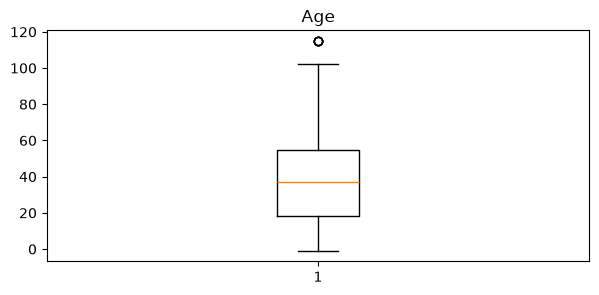

Q1: 18.0
Q3: 55.0
IQR: 37.0
하한: -37.5
상한: 110.5

이상치 후보 개수: 5
하위 이상치 후보:
63912    115
63915    115
68127    115
76284    115
97666    115
Name: Age, dtype: int64

상위 이상치 후보:
63912    115
63915    115
68127    115
76284    115
97666    115
Name: Age, dtype: int64
Age = -1 개수: 1

Age = -1인 데이터:
          PatientId  AppointmentID Gender          ScheduledDay  \
99832  4.659432e+14        5775010      F  2016-06-06T08:58:13Z   

             AppointmentDay  Age Neighbourhood  Scholarship  Hipertension  \
99832  2016-06-06T00:00:00Z   -1         ROMÃO            0             0   

       Diabetes  Alcoholism  Handcap  SMS_received No-show  
99832         0           0        0             0      No  
- Age = -1 → 실제 나이로 불가능하므로 입력 오류 또는 특수 결측값 후보
- IQR 기준 이상치 → 통계적으로 극단적인 값일 뿐, 실제 이상치라고 확정할 수 없음
- 정상적인 고령 환자의 나이 → 진짜 관측값일 수 있으므로 삭제하지 않음
- 현실적으로 불가능한 높은 나이 → 입력/기록 오류 가능성 검토
- Age = -1 → 원자료의 의미를 확인한 후 결측치 처리 검토
- 정상적인 고령 나이 → 삭제하지 않고 유지
- 비현실적인 나이 → 원자료 확인 후 수정 또는 결측 처리 검토
- IQR 이상치라는 이유만으로 

In [16]:
# 문제 3-1 코드를 작성하세요.


print(appointments["Age"].describe())

pig, ax=plt.subplots(figsize=(7, 3))
ax.boxplot(appointments["Age"].dropna())
ax.set_title("Age Boxplot")
ax.set_title("Age")
plt.show()


# 3. IQR 기준 이상치 후보 탐지
Q1 = appointments["Age"].quantile(0.25)
Q3 = appointments["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = appointments[
    (appointments["Age"] < lower_bound) |
    (appointments["Age"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("하한:", lower_bound)
print("상한:", upper_bound)

print("\n이상치 후보 개수:", len(outliers))



print("하위 이상치 후보:")
print(outliers["Age"].sort_values().head(10))

print("\n상위 이상치 후보:")
print(outliers["Age"].sort_values(ascending=False).head(10))


minus_one_count = (appointments["Age"] == -1).sum()

print("Age = -1 개수:", minus_one_count)

if minus_one_count > 0:
    print("\nAge = -1인 데이터:")
    print(appointments[appointments["Age"] == -1])


if minus_one_count > 0:
    print("- Age = -1 → 실제 나이로 불가능하므로 입력 오류 또는 특수 결측값 후보")

print("- IQR 기준 이상치 → 통계적으로 극단적인 값일 뿐, 실제 이상치라고 확정할 수 없음")
print("- 정상적인 고령 환자의 나이 → 진짜 관측값일 수 있으므로 삭제하지 않음")
print("- 현실적으로 불가능한 높은 나이 → 입력/기록 오류 가능성 검토")


print("- Age = -1 → 원자료의 의미를 확인한 후 결측치 처리 검토")
print("- 정상적인 고령 나이 → 삭제하지 않고 유지")
print("- 비현실적인 나이 → 원자료 확인 후 수정 또는 결측 처리 검토")
print("- IQR 이상치라는 이유만으로 값을 삭제하거나 수정하지 않음")

### 문제 3-1 결과 해석
- IQR 기준 이상치 후보 수:
- Age 최솟값:
- Age 최댓값:
- Age = -1 판단:
- 매우 높은 Age 값 판단:
- 지금 단계에서 삭제/수정하지 않는 이유:

---

# 실습 마무리

1. 결측치, 중복, 이상치를 왜 서로 다르게 접근해야 하나요?
2. AppointmentID 중복과 PatientId 반복은 왜 다르게 봐야 하나요?
3. MCAR / MAR / MNAR 중 가장 처리하기 어려운 것은 무엇인가요?
4. 이상치를 발견했다고 바로 제거하면 안 되는 이유는 무엇인가요?
5. 2장 1강에서 탐지만 하고 실제 수정은 하지 않는 이유는 무엇인가요?